In [1]:
!pip install tweepy

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

   ---------------------------------------- 0/3 [oauthlib]
   ------------- -------------------------- 1/3 [requests-oauthlib]
   -------------------------- ------------- 2/3 [tweepy]
   ---------------------------------------- 3/3 [tweepy]




[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Libraries

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import os
import tweepy as tw #for accessing Twitter API


#For Preprocessing
import re    # RegEx for removing non-letter characters
import nltk  #natural language processing
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem.porter import *

# For Building the model
from sklearn.model_selection import train_test_split
import tensorflow as tf
import seaborn as sns

#For data visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

#pd.options.plotting.backend = "plotly"

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#Load DataSet

In [4]:
df = pd.read_csv('apple-twitter-sentiment-texts.csv')

In [5]:
df

,text,sentiment
0,Wow. Yall needa step it up @Apple RT @heynyla:...,-1
1,What Happened To Apple Inc? http://t.co/FJEX...,0
2,Thank u @apple I can now compile all of the pi...,1
3,The oddly uplifting story of the Apple co-foun...,0
4,@apple can i exchange my iphone for a differen...,0
...,...,...
1625,Those** PICK UP THE SLACK YOU FUCK BOYS @Apple,-1
1626,Finally got my iPhone 6 in the mail and it com...,-1
1627,@umo_games @Apple ended up getting a new compu...,0
1628,The 19-Year-Old #WizKid Who Turned Down @Apple...,0


In [6]:
# Load Tweet dataset
# df = pd.read_csv('apple-twitter-sentiment-texts.csv')
df = df.rename(columns={'text': 'clean_text', 'sentiment':'category'})
df['category'] = df['category'].map({-1: -1.0, 0: 0.0, 1:1.0})
# Output first five rows

df.head()


,clean_text,category
0,Wow. Yall needa step it up @Apple RT @heynyla:...,-1.0
1,What Happened To Apple Inc? http://t.co/FJEX...,0.0
2,Thank u @apple I can now compile all of the pi...,1.0
3,The oddly uplifting story of the Apple co-foun...,0.0
4,@apple can i exchange my iphone for a differen...,0.0


In [7]:
# Check for missing data
df.isnull().sum()

clean_text    0
category      0
dtype: int64

In [8]:
# dimensionality of the data
df.shape

(1630, 2)

In [9]:
df['category'] = df['category'].map({-1.0:'Negative', 0.0:'Neutral', 1.0:'Positive'})

# Output first five rows
df.head()

,clean_text,category
0,Wow. Yall needa step it up @Apple RT @heynyla:...,Negative
1,What Happened To Apple Inc? http://t.co/FJEX...,Neutral
2,Thank u @apple I can now compile all of the pi...,Positive
3,The oddly uplifting story of the Apple co-foun...,Neutral
4,@apple can i exchange my iphone for a differen...,Neutral


#Exploratory Data Analysis

<Axes: xlabel='category'>

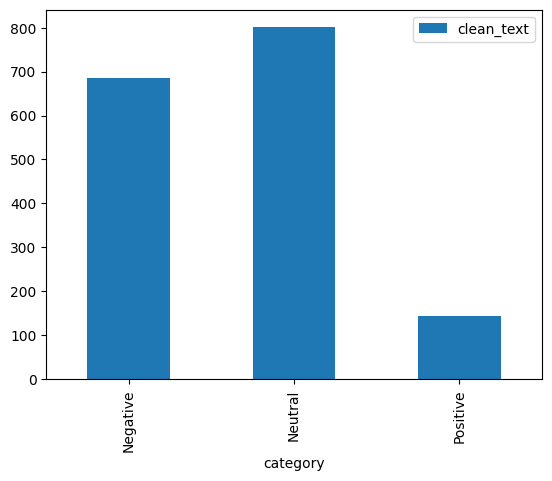

In [10]:
# The distribution of sentiments
df.groupby('category').count().plot(kind='bar')

<Axes: >

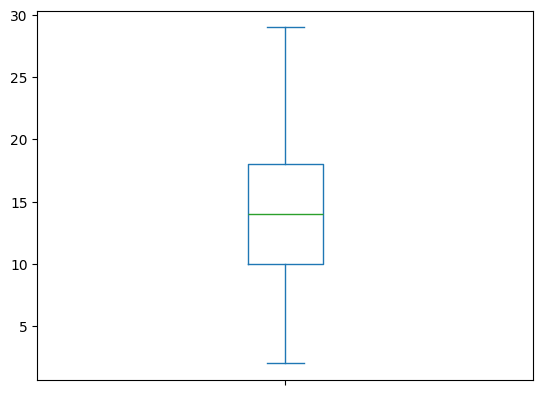

In [11]:
# Calculate tweet lengths
tweet_len = pd.Series([len(tweet.split()) for tweet in df['clean_text']])

# The distribution of tweet text lengths
tweet_len.plot(kind='box')

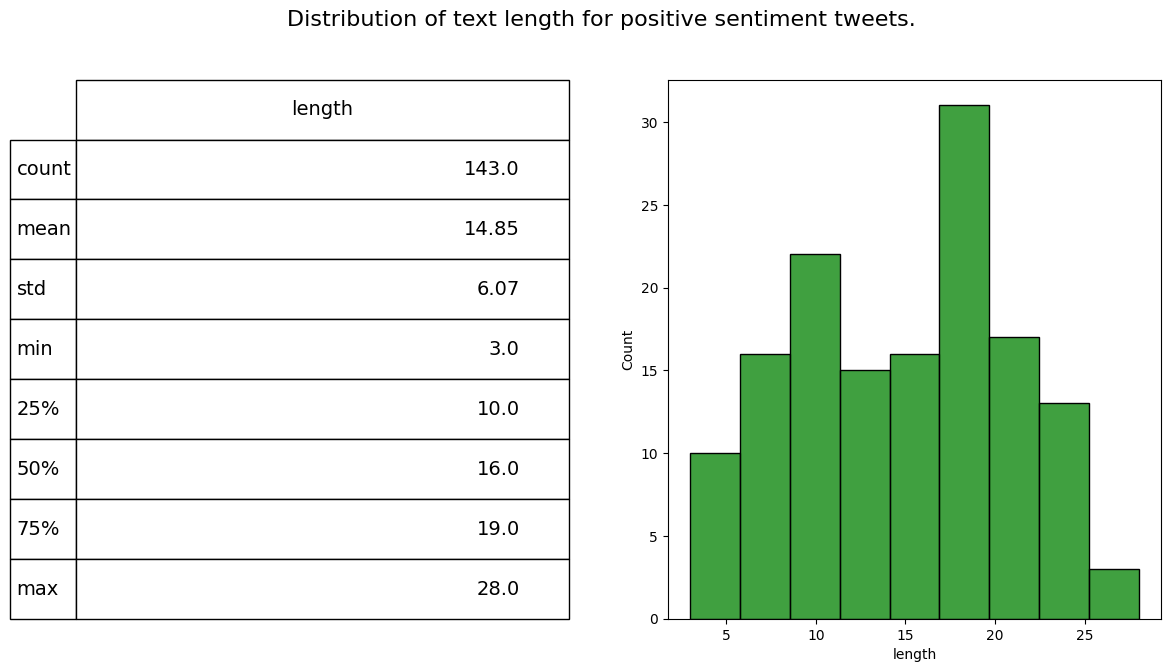

In [12]:
fig = plt.figure(figsize=(14,7))
df['length'] = df.clean_text.str.split().apply(len)
ax1 = fig.add_subplot(122)
sns.histplot(df[df['category']=='Positive']['length'], ax=ax1,color='green')
describe = df.length[df.category=='Positive'].describe().to_frame().round(2)

ax2 = fig.add_subplot(121)
ax2.axis('off')
font_size = 14
bbox = [0, 0, 1, 1]
table = ax2.table(cellText = describe.values, rowLabels = describe.index, bbox=bbox, colLabels=describe.columns)
table.set_fontsize(font_size)
fig.suptitle('Distribution of text length for positive sentiment tweets.', fontsize=16)

plt.show()

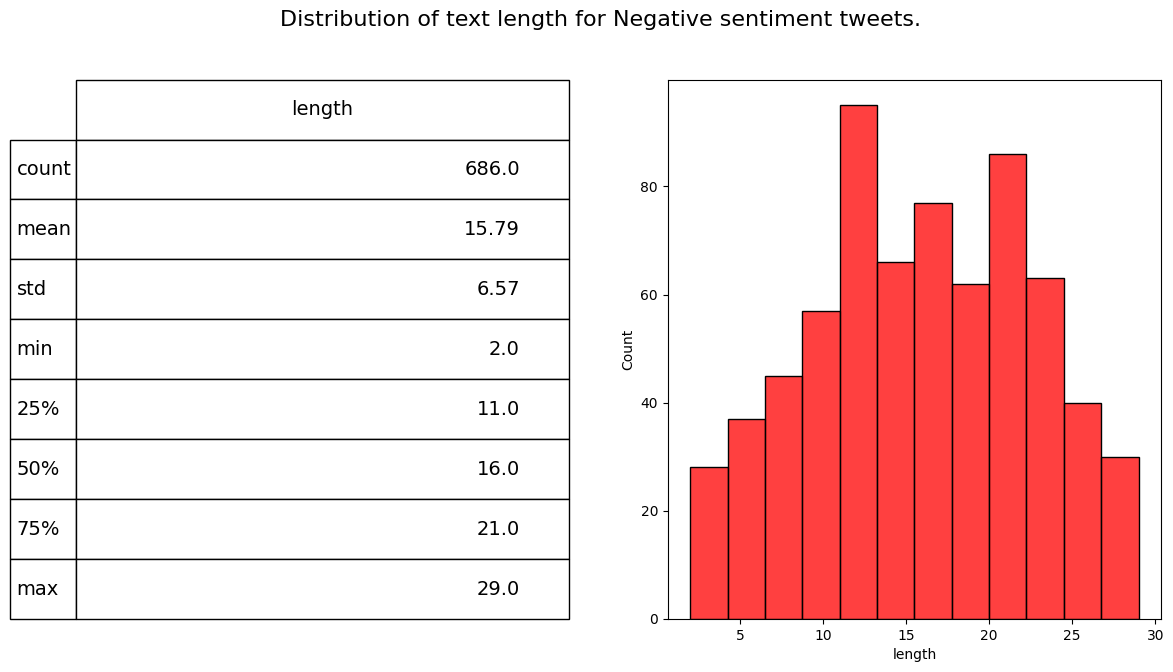

In [13]:
fig = plt.figure(figsize=(14,7))
df['length'] = df.clean_text.str.split().apply(len)
ax1 = fig.add_subplot(122)
sns.histplot(df[df['category']=='Negative']['length'], ax=ax1,color='red')
describe = df.length[df.category=='Negative'].describe().to_frame().round(2)

ax2 = fig.add_subplot(121)
ax2.axis('off')
font_size = 14
bbox = [0, 0, 1, 1]
table = ax2.table(cellText = describe.values, rowLabels = describe.index, bbox=bbox, colLabels=describe.columns)
table.set_fontsize(font_size)
fig.suptitle('Distribution of text length for Negative sentiment tweets.', fontsize=16)

plt.show()

In [15]:
# import plotly.express as px
# fig = px.pie(df, names='category', title ='Pie chart of different sentiments of tweets')
# fig.show()

#Data Preprocessing

In [17]:
def tweet_to_words(tweet):
    ''' Convert tweet text into a sequence of words '''

    # convert to lowercase
    text = tweet.lower()
    # remove non letters
    text = re.sub(r"[^a-zA-Z0-9]", " ", text)
    # tokenize
    words = text.split()
    # remove stopwords
    words = [w for w in words if w not in stopwords.words("english")]
    #print(words)
    # apply stemming
    words = [PorterStemmer().stem(w) for w in words]
    # return list
    return words

print("\nOriginal tweet ->", df['clean_text'][0])
print("\nProcessed tweet ->", tweet_to_words(df['clean_text'][0]))


Original tweet -> Wow. Yall needa step it up @Apple RT @heynyla: Music and snapchat at the same damn time. Thank you #Note4
['wow', 'yall', 'needa', 'step', 'apple', 'rt', 'heynyla', 'music', 'snapchat', 'damn', 'time', 'thank', 'note4']

Processed tweet -> ['wow', 'yall', 'needa', 'step', 'appl', 'rt', 'heynyla', 'music', 'snapchat', 'damn', 'time', 'thank', 'note4']


In [ ]:
tweet_to_words

In [ ]:
(map(tweet_to_words, df['clean_text'])

In [19]:
# Apply data processing to each tweet
X = list(map(tweet_to_words, df['clean_text']))

['wow', 'yall', 'needa', 'step', 'apple', 'rt', 'heynyla', 'music', 'snapchat', 'damn', 'time', 'thank', 'note4']
['happened', 'apple', 'inc', 'http', 'co', 'fjexi3op0u', 'aapl', 'apple', 'moneypress', 'http', 'co', 'wxkmmtmarw']
['thank', 'u', 'apple', 'compile', 'pics', 'communicate', 'one', 'place', 'http', 'co', 'tq1lo09oya']
['oddly', 'uplifting', 'story', 'apple', 'co', 'founder', 'sold', 'stake', '800', 'aapl', 'aapl', 'http', 'co', 'cizbvr05pj']
['apple', 'exchange', 'iphone', 'different', 'color', 'lmao', 'changed', 'mind']
['rt', 'jpdesloges', 'apple', 'acted', 'unfairly', 'suppressing', 'digital', 'music', 'competition', 'paul', 'kedrosky', 'aapl', 'aapl', 'http', 'co', 'xtbfhpbyf7']
['let', 'forget', 'press', 'effects', 'stock', 'apple', 'defend', 'ipod', 'antitrust', 'suit', 'http', 'co', 'pqj0bkimb8']
['apple', 'inc', 'deleted', 'songs', 'rival', 'services', 'ipods', 'http', 'co', 'dqwdfpcc4x', 'aapl']
['teamcavuto', 'apple', 'staging', 'die', 'ar', 'apple', 'store', 'iph

In [21]:
#X

In [22]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
Y = le.fit_transform(df['category'])

In [23]:
Y

array([0, 1, 2, ..., 1, 1, 0], shape=(1630,))

In [24]:
print(X[0])
print(Y[0])

['wow', 'yall', 'needa', 'step', 'appl', 'rt', 'heynyla', 'music', 'snapchat', 'damn', 'time', 'thank', 'note4']
0


In [26]:
y

,Negative,Neutral,Positive
0,True,False,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,True,False
...,...,...,...
1625,True,False,False
1626,True,False,False
1627,False,True,False
1628,False,True,False


In [25]:
y = pd.get_dummies(df['category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.feature_extraction.text import TfidfVectorizer

vocabulary_size = 5000

# Tweets have already been preprocessed hence dummy function will be passed in
# to preprocessor & tokenizer step
count_vector = CountVectorizer(max_features=vocabulary_size,
#                               ngram_range=(1,2),    # unigram and bigram
                                preprocessor=lambda x: x,
                               tokenizer=lambda x: x)
#tfidf_vector = TfidfVectorizer(lowercase=True, stop_words='english')

# Fit the training data
X_train = count_vector.fit_transform(X_train).toarray()

# Transform testing data
X_test = count_vector.transform(X_test).toarray()

D:\new_compant\Training\test\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [28]:
# print first 200 words/tokens
print(count_vector.get_feature_names_out()[0:200])

['0' '00' '000' '07' '08' '09' '0cutgtm7ff' '0k1vgdqhqe' '0kxphcf28k'
 '0mo7dueyh6' '0xbmuvdzpl' '1' '10' '100' '109' '11' '112' '113' '115'
 '11am' '11th' '12' '1215' '128g' '128gb' '13' '130' '135' '13in' '14'
 '140' '14uhvycp6b' '15' '150' '16' '161' '161m' '164' '169' '16qbqo1prk'
 '17' '170' '18' '18th' '19' '1984' '1996' '19g2jyzogi' '1amktieki' '1bn'
 '1bwd8k32gv' '1fqopihobo' '1rsxt3cmlz' '1st' '1x62rp5r8i' '1yrnuvcjel'
 '2' '20' '200' '2000' '2002' '2007' '2011' '2014' '2014q3' '2015' '21'
 '22' '23' '24' '24inch' '24k' '26' '2600' '29' '2ca2sfashg' '2cfrytgvom'
 '2wpaib3z9m' '2xlmdi61hf' '3' '30' '31' '330' '33xsma4r9j' '34' '360'
 '37' '3d' '3g' '3qdigit' '3rd' '3vouta45gb' '3ytd8iz62i' '4' '40' '41'
 '42' '42mjc3ssje' '45' '4500' '48' '49' '4exiskmcmv' '4in' '4s'
 '4wrgdhxi0g' '5' '50' '500' '5000' '515obkajdk' '51hqnc7s2o' '550' '56'
 '58j6kpmili' '59vmgqr0th' '5abnwwvqxh' '5ajvsqxgdn' '5bnaihk58p'
 '5djc9keuqp' '5jygticwlc' '5o26s4zrqc' '5plks2lrtt' '5pzl2wa9sv' '5s'
 '5s

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 5000
max_len=50

def tokenize_pad_sequences(text):
    '''
    This function tokenize the input text into sequnences of intergers and then
    pad each sequence to the same length
    '''
    # Text tokenization
    tokenizer = Tokenizer(num_words=max_words, lower=True, split=' ')
    tokenizer.fit_on_texts(text)
    # Transforms text to a sequence of integers
    X = tokenizer.texts_to_sequences(text)
    # Pad sequences to the same length
    X = pad_sequences(X, padding='post', maxlen=max_len)
    # return sequences
    return X, tokenizer

print('Before Tokenization & Padding \n', df['clean_text'][1])
X, tokenizer = tokenize_pad_sequences(df['clean_text'])
print('After Tokenization & Padding \n', X[1])

Before Tokenization & Padding 
 What Happened To Apple Inc?   http://t.co/FJEXI3oP0U  #aapl #apple @MoneyPress http://t.co/wXKmmTMArW
After Tokenization & Padding 
 [  48  310    6    1   43    4    2    3 2023    7    1 2024    4    2
    3 2025    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [32]:
len(X[0])

50

In [33]:
import pickle

# saving
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# loading
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

In [35]:
y = pd.get_dummies(df['category'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)
print('Train Set ->', X_train.shape, y_train.shape)
print('Validation Set ->', X_val.shape, y_val.shape)
print('Test Set ->', X_test.shape, y_test.shape)

Train Set -> (978, 50) (978, 3)
Validation Set -> (326, 50) (326, 3)
Test Set -> (326, 50) (326, 3)


In [39]:
X_train

array([[   1,  395,  396, ...,    0,    0,    0],
       [  20, 2455,    5, ...,    0,    0,    0],
       [   1,    1,  623, ...,    0,    0,    0],
       ...,
       [   1,  102,    8, ...,    0,    0,    0],
       [  80,  336,    1, ...,    0,    0,    0],
       [   1, 3417, 3418, ...,    0,    0,    0]],
      shape=(978, 50), dtype=int32)

In [36]:
import keras.backend as K

def f1_score(precision, recall):
    ''' Function to calculate f1 score '''

    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

# Bidirectional LSTM Using NN

In [49]:
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
from keras.metrics import Precision, Recall
from keras.optimizers import SGD
from keras.optimizers import RMSprop
from keras import datasets

from keras.callbacks import LearningRateScheduler
from keras.callbacks import History

from keras import losses

vocab_size = 5000
embedding_size = 32
epochs=20
learning_rate = 1.0
decay_rate = learning_rate / epochs
momentum = 0.8

sgd = SGD(learning_rate=learning_rate, momentum=momentum, nesterov=False)
# Build model
model= Sequential()
model.add(Embedding(vocab_size, embedding_size, input_length=max_len))
model.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.4))
model.add(Dense(3, activation='softmax'))

D:\new_compant\Training\test\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
import tensorflow as tf
model.build(input_shape=(None, max_len))
tf.keras.utils.plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [50]:
print(model.summary())

# Compile model
model.compile(loss='categorical_crossentropy', optimizer=sgd,
               metrics=['accuracy', Precision(), Recall()])

# Train model

batch_size = 64
history = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      batch_size=batch_size, epochs=epochs, verbose=1)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.4959 - loss: 0.9759 - precision_2: 0.5091 - recall_2: 0.3701 - val_accuracy: 0.4601 - val_loss: 0.9637 - val_precision_2: 0.4601 - val_recall_2: 0.4601
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4427 - loss: 0.9947 - precision_2: 0.4389 - recall_2: 0.3712 - val_accuracy: 0.4601 - val_loss: 0.9273 - val_precision_2: 0.0000e+00 - val_recall_2: 0.0000e+00
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.4652 - loss: 0.9506 - precision_2: 0.4648 - recall_2: 0.2566 - val_accuracy: 0.4601 - val_loss: 1.0042 - val_precision_2: 0.4601 - val_recall_2: 0.4601
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4663 - loss: 0.9626 - precision_2: 0.4536 - recall_2: 0.3395 - val_accuracy: 0.4601 - val_loss: 1.0026 - val_precision_2: 0.4601 - val_recall_2: 0.4601
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4509 - loss: 0.9482 - precision_2: 0.4584 - recall_2:

In [51]:
# Evaluate model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)
# Print metrics
print('')
print('Accuracy  : {:.4f}'.format(accuracy))
print('Precision : {:.4f}'.format(precision))
print('Recall    : {:.4f}'.format(recall))
print('F1 Score  : {:.4f}'.format(f1_score(precision, recall)))


Accuracy  : 0.6442
Precision : 0.6502
Recall    : 0.6442
F1 Score  : 0.6471


In [52]:
history

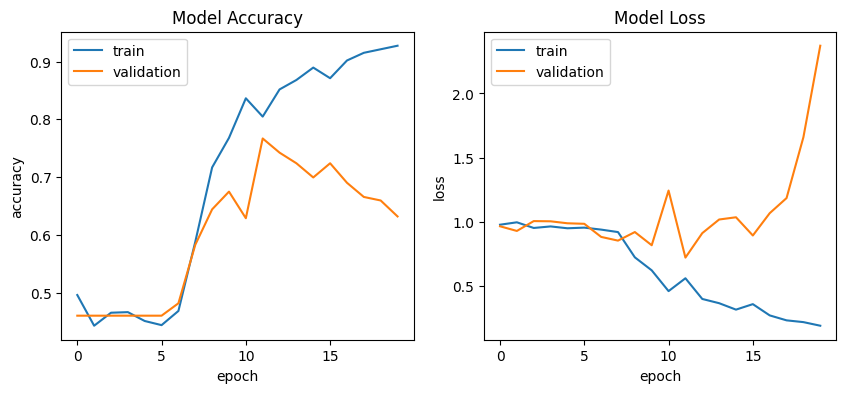

In [53]:
def plot_training_hist(history):
    '''Function to plot history for accuracy and loss'''

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # first plot
    ax[0].plot(history.history['accuracy'])
    ax[0].plot(history.history['val_accuracy'])
    ax[0].set_title('Model Accuracy')
    ax[0].set_xlabel('epoch')
    ax[0].set_ylabel('accuracy')
    ax[0].legend(['train', 'validation'], loc='best')
    # second plot
    ax[1].plot(history.history['loss'])
    ax[1].plot(history.history['val_loss'])
    ax[1].set_title('Model Loss')
    ax[1].set_xlabel('epoch')
    ax[1].set_ylabel('loss')
    ax[1].legend(['train', 'validation'], loc='best')

plot_training_hist(history)